In [2]:
import pandas as pd
import numpy as np
import re
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliothèques importées avec succès")


✅ Bibliothèques importées avec succès


In [3]:
# 2. FONCTION DE NETTOYAGE DU TEXTE
# =============================================================================
def clean_text(text):
    """
    Nettoie le texte en supprimant les caractères indésirables
    """
    if pd.isna(text) or text == '':
        return ''
    
    # Convertir en string
    text = str(text)
    
    # Supprimer les caractères répétitifs (ex: fffffffff)
    text = re.sub(r'(.)\1{4,}', r'\1\1', text)
    
    # Supprimer les caractères spéciaux excessifs
    text = re.sub(r'[!]{2,}', '!', text)
    text = re.sub(r'[?]{2,}', '?', text)
    text = re.sub(r'[.]{2,}', '.', text)
    
    # Supprimer les emojis et caractères non-textuels problématiques
    text = re.sub(r'[^\w\s\u0600-\u06FF\u0750-\u077F\u08A0-\u08FF\uFB50-\uFDFF\uFE70-\uFEFF!?.,;:]', ' ', text)
    
    # Supprimer les espaces multiples
    text = re.sub(r'\s+', ' ', text)
    
    # Supprimer les espaces en début et fin
    text = text.strip()
    
    return text

print("✅ Fonction de nettoyage définie")

✅ Fonction de nettoyage définie


In [4]:
# =============================================================================
print("\n" + "="*50)
print("CHARGEMENT DES DONNÉES")
print("="*50)

# Chargement du dataset
try:
    df = pd.read_csv('final_data.csv')
    print(f"✅ Dataset chargé avec succès: {df.shape[0]} lignes, {df.shape[1]} colonnes")
except FileNotFoundError:
    print("❌ Erreur: Fichier 'dataset-final.csv' non trouvé")
    exit()


CHARGEMENT DES DONNÉES
✅ Dataset chargé avec succès: 20339 lignes, 2 colonnes


In [5]:
# Affichage des premières lignes
print("\nPremières lignes du dataset:")
print(df.head())


Premières lignes du dataset:
                                       text  intent
0                 0000000000000000000 nulle     0.0
1                          marzen mleyektou     0.0
2  يا سي امين ممسطك وليت والله بففففففففففف     0.0
3                            M3alem hhhhhhh     1.0
4                              عسل حسين عسل     1.0


In [6]:
# Informations sur le dataset
print(f"\nInformations sur le dataset:")
print(f"- Nombre total de lignes: {len(df)}")
print(f"- Colonnes: {list(df.columns)}")
print(f"- Valeurs manquantes:")
print(df.isnull().sum())

# Distribution des classes
print(f"\nDistribution des classes:")
print(df['intent'].value_counts())



Informations sur le dataset:
- Nombre total de lignes: 20339
- Colonnes: ['text', 'intent']
- Valeurs manquantes:
text      40
intent    26
dtype: int64

Distribution des classes:
intent
0.0    10335
1.0     9978
Name: count, dtype: int64


In [7]:
# 4. NETTOYAGE ET PRÉPARATION DES DONNÉES
# =============================================================================
print("\n" + "="*50)
print("NETTOYAGE DES DONNÉES")
print("="*50)

# Supprimer les lignes avec des valeurs manquantes
df_clean = df.dropna().copy()
print(f"Après suppression des valeurs manquantes: {len(df_clean)} lignes")

# Nettoyer le texte
print("Nettoyage du texte en cours...")
df_clean['text_cleaned'] = df_clean['text'].apply(clean_text)

# Supprimer les textes vides après nettoyage
df_clean = df_clean[df_clean['text_cleaned'] != ''].copy()
print(f"Après suppression des textes vides: {len(df_clean)} lignes")

# Afficher quelques exemples de nettoyage
print("\nExemples de nettoyage:")
for i in range(min(5, len(df_clean))):
    original = df_clean.iloc[i]['text']
    cleaned = df_clean.iloc[i]['text_cleaned']
    print(f"Original: {original}")
    print(f"Nettoyé:  {cleaned}")
    print("-" * 40)


NETTOYAGE DES DONNÉES
Après suppression des valeurs manquantes: 20273 lignes
Nettoyage du texte en cours...
Après suppression des textes vides: 19450 lignes

Exemples de nettoyage:
Original: 0000000000000000000 nulle
Nettoyé:  00 nulle
----------------------------------------
Original: marzen mleyektou
Nettoyé:  marzen mleyektou
----------------------------------------
Original: يا سي امين ممسطك وليت والله بففففففففففف
Nettoyé:  يا سي امين ممسطك وليت والله بفف
----------------------------------------
Original: M3alem hhhhhhh
Nettoyé:  M3alem hh
----------------------------------------
Original: عسل حسين عسل
Nettoyé:  عسل حسين عسل
----------------------------------------


In [8]:
print("\n" + "="*50)
print("PRÉPARATION POUR L'ENTRAÎNEMENT")
print("="*50)

# Séparer les features et les labels
X = df_clean['text_cleaned'].values
y = df_clean['intent'].values

print(f"Nombre d'échantillons: {len(X)}")
print(f"Classes uniques: {np.unique(y)}")


PRÉPARATION POUR L'ENTRAÎNEMENT
Nombre d'échantillons: 19450
Classes uniques: [0. 1.]


In [9]:
# Division train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
print("\n" + "="*50)
print("VECTORISATION")
print("="*50)

# Création du vectoriseur TF-IDF
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words=None,  # Garder tous les mots pour les langues mixtes
    min_df=2,
    max_df=0.95
)

# Ajustement et transformation
print("Vectorisation en cours...")
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"✅ Vectorisation terminée")
print(f"Forme des données d'entraînement: {X_train_vec.shape}")
print(f"Forme des données de test: {X_test_vec.shape}")


VECTORISATION
Vectorisation en cours...
✅ Vectorisation terminée
Forme des données d'entraînement: (15560, 5000)
Forme des données de test: (3890, 5000)


In [11]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn import metrics
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def multiclass_roc_auc_score(y_true, y_pred, average="macro"):
    from sklearn.preprocessing import LabelBinarizer
    lb = LabelBinarizer()
    lb.fit(y_true)
    y_true_bin = lb.transform(y_true)
    y_pred_bin = lb.transform(y_pred)
    return roc_auc_score(y_true_bin, y_pred_bin, average=average)

def evaluate_model(model, X_train, y_train):
    """Cross-validation sur accuracy"""
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
    return cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=4)

def Model_Evaluation1(model, model_name, X_train, y_train, X_test, y_test, result_tabulation):
    # 1) Prédictions
    model_pred = model.predict(X_test)
    
    # 2) Matrice de confusion
    cm = confusion_matrix(y_test, model_pred)
    conf_matrix = pd.DataFrame(
        data=cm,
        columns=[f'P_{cls}' for cls in np.unique(y_test)],
        index=[f'A_{cls}' for cls in np.unique(y_test)]
    )
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="YlGnBu")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.show()

    # 3) Rapport de classification
    print(f"\nClassification Report – {model_name}\n")
    print(classification_report(y_test, model_pred, zero_division=0))

    # 4) Validation croisée
    cv_accuracy = evaluate_model(model, X_train, y_train)

    # 5) Récapitulatif des métriques
    model_eva = pd.Series({
        'Model'          : model_name,
        'AUC Score'      : multiclass_roc_auc_score(y_test, model_pred),
        'MCC'            : metrics.matthews_corrcoef(y_test, model_pred),
        'Precision Score': metrics.precision_score(y_test, model_pred, average='weighted', zero_division=0),
        'Recall Score'   : metrics.recall_score(y_test, model_pred, average='weighted', zero_division=0),
        'f1-score'       : metrics.f1_score(y_test, model_pred, average='weighted', zero_division=0),
        'Accuracy Score' : metrics.accuracy_score(y_test, model_pred),
        'Train Accuracy' : model.score(X_train, y_train),
        'CV'             : np.mean(cv_accuracy)
    })

    print(f"\nMetrics – {model_name}\n{model_eva}\n")

    # 6) Mettre à jour la table des résultats
    result_tabulation = pd.concat([result_tabulation, model_eva.to_frame().T], ignore_index=True)

    return result_tabulation


In [12]:
cols = ['Model', 'AUC Score','MCC', 'Precision Score', 'Recall Score','f1-score','Accuracy Score','Train Accuracy','CV']

In [13]:
result_tabulation = pd.DataFrame(columns = cols)
result_tabulation_rse1 = pd.DataFrame(columns = cols)


In [14]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, VotingClassifier
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC



Decision Tree TF-IDF CV accuracy: [0.82262211 0.84479434 0.83997429 0.83676093 0.84286632]
Moyenne: 0.8374, Écart-type: 0.0079


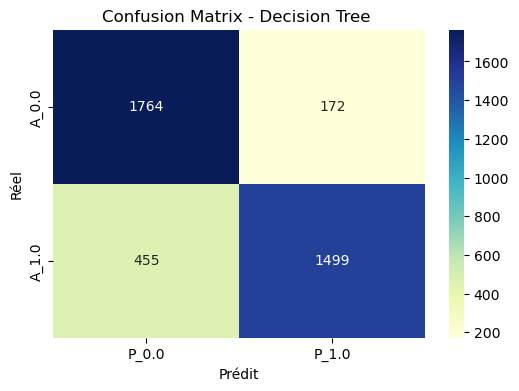


Classification Report – Decision Tree 

              precision    recall  f1-score   support

         0.0       0.79      0.91      0.85      1936
         1.0       0.90      0.77      0.83      1954

    accuracy                           0.84      3890
   macro avg       0.85      0.84      0.84      3890
weighted avg       0.85      0.84      0.84      3890


Metrics – Decision Tree 
Model              Decision Tree 
AUC Score                0.839151
MCC                      0.685126
Precision Score          0.846246
Recall Score             0.838817
f1-score                 0.838015
Accuracy Score           0.838817
Train Accuracy           0.950964
CV                       0.838046
dtype: object



In [15]:
# --- Decision Tree sur TF-IDF ---
dt_tfidf = DecisionTreeClassifier(random_state=200)
cv_scores = cross_val_score(dt_tfidf, X_train_vec, y_train, cv=5, scoring='accuracy')
print(f"Decision Tree TF-IDF CV accuracy: {cv_scores}")
print(f"Moyenne: {np.mean(cv_scores):.4f}, Écart-type: {np.std(cv_scores):.4f}")
dt_tfidf.fit(X_train_vec, y_train)
result_tabulation = Model_Evaluation1(dt_tfidf, "Decision Tree ", X_train_vec , y_train, X_test_vec, y_test, result_tabulation)


Decision Tree TF-IDF CV accuracy: [0.8785347  0.88624679 0.87821337 0.89460154 0.88592545]
Moyenne: 0.8847, Écart-type: 0.0060


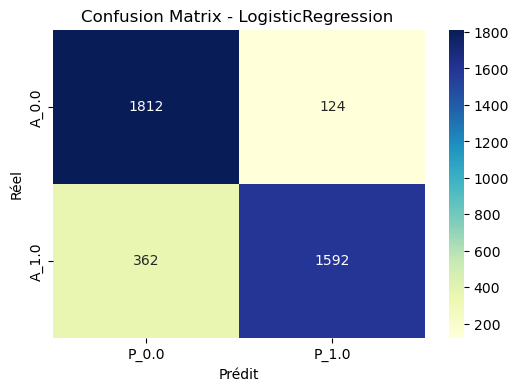


Classification Report – LogisticRegression 

              precision    recall  f1-score   support

         0.0       0.83      0.94      0.88      1936
         1.0       0.93      0.81      0.87      1954

    accuracy                           0.88      3890
   macro avg       0.88      0.88      0.87      3890
weighted avg       0.88      0.88      0.87      3890


Metrics – LogisticRegression 
Model              LogisticRegression 
AUC Score                     0.875345
MCC                           0.755939
Precision Score               0.880831
Recall Score                  0.875064
f1-score                      0.874631
Accuracy Score                0.875064
Train Accuracy                0.916452
CV                            0.883033
dtype: object



In [16]:
# --- Decision Tree sur TF-IDF ---
lg_tfidf =LogisticRegression(random_state=200)
cv_scores = cross_val_score(lg_tfidf, X_train_vec, y_train, cv=5, scoring='accuracy')
print(f"Decision Tree TF-IDF CV accuracy: {cv_scores}")
print(f"Moyenne: {np.mean(cv_scores):.4f}, Écart-type: {np.std(cv_scores):.4f}")
lg_tfidf.fit(X_train_vec, y_train)
result_tabulation = Model_Evaluation1(lg_tfidf, "LogisticRegression ", X_train_vec , y_train, X_test_vec, y_test, result_tabulation)


Decision Tree TF-IDF CV accuracy: [0.88592545 0.88978149 0.88688946 0.89781491 0.88624679]
Moyenne: 0.8893, Écart-type: 0.0045


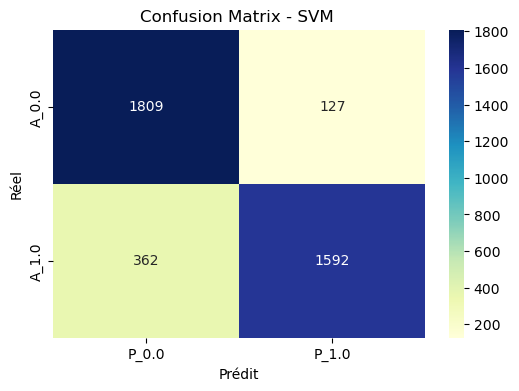


Classification Report – SVM 

              precision    recall  f1-score   support

         0.0       0.83      0.93      0.88      1936
         1.0       0.93      0.81      0.87      1954

    accuracy                           0.87      3890
   macro avg       0.88      0.87      0.87      3890
weighted avg       0.88      0.87      0.87      3890


Metrics – SVM 
Model                  SVM 
AUC Score           0.87457
MCC                0.754241
Precision Score    0.879903
Recall Score       0.874293
f1-score           0.873868
Accuracy Score     0.874293
Train Accuracy     0.944023
CV                 0.887243
dtype: object



In [17]:
# --- Decision Tree sur TF-IDF ---
svm_tfidf =SVC()
cv_scores = cross_val_score(svm_tfidf, X_train_vec, y_train, cv=5, scoring='accuracy')
print(f"Decision Tree TF-IDF CV accuracy: {cv_scores}")
print(f"Moyenne: {np.mean(cv_scores):.4f}, Écart-type: {np.std(cv_scores):.4f}")
svm_tfidf.fit(X_train_vec, y_train)
result_tabulation = Model_Evaluation1(svm_tfidf, "SVM ", X_train_vec , y_train, X_test_vec, y_test, result_tabulation)


Decision Tree TF-IDF CV accuracy: [0.77056555 0.76028278 0.76092545 0.74839332 0.76799486]
Moyenne: 0.7616, Écart-type: 0.0077


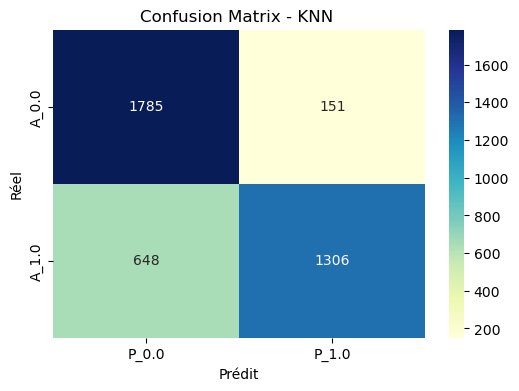


Classification Report – KNN 

              precision    recall  f1-score   support

         0.0       0.73      0.92      0.82      1936
         1.0       0.90      0.67      0.77      1954

    accuracy                           0.79      3890
   macro avg       0.82      0.80      0.79      3890
weighted avg       0.82      0.79      0.79      3890


Metrics – KNN 
Model                  KNN 
AUC Score          0.795188
MCC                0.609879
Precision Score    0.815389
Recall Score       0.794602
f1-score            0.79132
Accuracy Score     0.794602
Train Accuracy     0.872751
CV                 0.762886
dtype: object



In [18]:
# --- Decision Tree sur TF-IDF ---
KNN =KNeighborsClassifier()
cv_scores = cross_val_score(KNN, X_train_vec, y_train, cv=5, scoring='accuracy')
print(f"Decision Tree TF-IDF CV accuracy: {cv_scores}")
print(f"Moyenne: {np.mean(cv_scores):.4f}, Écart-type: {np.std(cv_scores):.4f}")
KNN.fit(X_train_vec, y_train)
result_tabulation = Model_Evaluation1(KNN, "KNN ", X_train_vec , y_train, X_test_vec, y_test, result_tabulation)


In [19]:
result_tabulation

,Model,AUC Score,MCC,Precision Score,Recall Score,f1-score,Accuracy Score,Train Accuracy,CV
0,Decision Tree,0.839151,0.685126,0.846246,0.838817,0.838015,0.838817,0.950964,0.838046
1,LogisticRegression,0.875345,0.755939,0.880831,0.875064,0.874631,0.875064,0.916452,0.883033
2,SVM,0.87457,0.754241,0.879903,0.874293,0.873868,0.874293,0.944023,0.887243
3,KNN,0.795188,0.609879,0.815389,0.794602,0.79132,0.794602,0.872751,0.762886


In [20]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Logistic Regression params: {'solver': 'saga', 'penalty': 'l2', 'max_iter': 1000, 'C': 10.0}


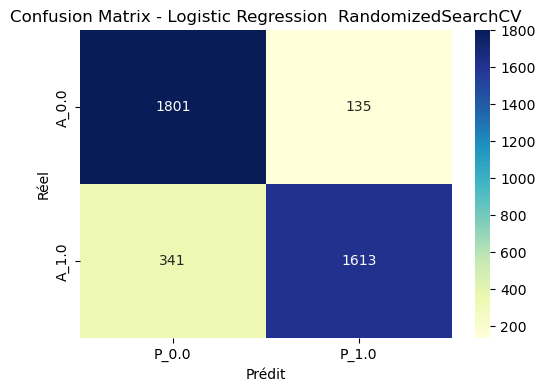


Classification Report – Logistic Regression  RandomizedSearchCV

              precision    recall  f1-score   support

         0.0       0.84      0.93      0.88      1936
         1.0       0.92      0.83      0.87      1954

    accuracy                           0.88      3890
   macro avg       0.88      0.88      0.88      3890
weighted avg       0.88      0.88      0.88      3890


Metrics – Logistic Regression  RandomizedSearchCV
Model              Logistic Regression  RandomizedSearchCV
AUC Score                                         0.877877
MCC                                               0.759653
Precision Score                                   0.881976
Recall Score                                      0.877635
f1-score                                          0.877321
Accuracy Score                                    0.877635
Train Accuracy                                    0.936375
CV                                                0.887468
dtype: object



In [21]:
param_dist_lr = {
    'C': np.logspace(-3, 3, 10),
    'solver': ['lbfgs', 'saga'],
    'penalty': ['l2'],
    'max_iter': [1000]
}

rs_lr = RandomizedSearchCV(
    LogisticRegression(),
    param_dist_lr,
    n_iter=20,
    scoring='accuracy',
    cv=5,
    n_jobs=4,
    verbose=1,
    random_state=42
)

rs_lr.fit(X_train_vec, y_train)
print("Best Logistic Regression params:", rs_lr.best_params_)

best_lr = rs_lr.best_estimator_

result_tabulation_rse1 = Model_Evaluation1(
    best_lr,
    "Logistic Regression  RandomizedSearchCV",
    X_train_vec, y_train,
    X_test_vec, y_test,
    result_tabulation_rse1
)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best SVC params: {'kernel': 'rbf', 'gamma': 'scale', 'C': 2.1544346900318843}


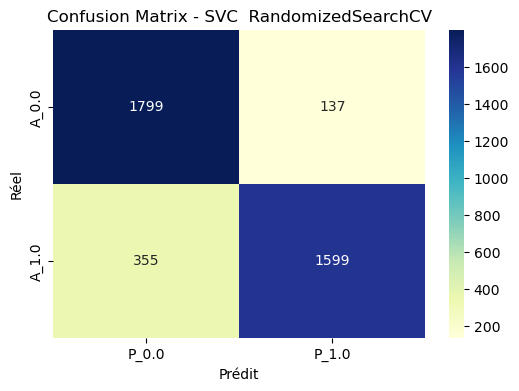


Classification Report – SVC  RandomizedSearchCV

              precision    recall  f1-score   support

         0.0       0.84      0.93      0.88      1936
         1.0       0.92      0.82      0.87      1954

    accuracy                           0.87      3890
   macro avg       0.88      0.87      0.87      3890
weighted avg       0.88      0.87      0.87      3890


Metrics – SVC  RandomizedSearchCV
Model              SVC  RandomizedSearchCV
AUC Score                         0.873778
MCC                               0.751902
Precision Score                   0.878335
Recall Score                      0.873522
f1-score                          0.873156
Accuracy Score                    0.873522
Train Accuracy                    0.949357
CV                                0.886343
dtype: object



In [22]:
param_dist_svc = {
    'C': np.logspace(-3, 2, 10),
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

rs_svc = RandomizedSearchCV(
    SVC(),
    param_dist_svc,
    n_iter=15,
    scoring='accuracy',
    cv=5,
    n_jobs=4,
    verbose=1,
    random_state=42
)

rs_svc.fit(X_train_vec, y_train)
print("Best SVC params:", rs_svc.best_params_)

best_svc = rs_svc.best_estimator_

result_tabulation_rse1 = Model_Evaluation1(
    best_svc,
    "SVC  RandomizedSearchCV",
    X_train_vec, y_train,
    X_test_vec, y_test,
    result_tabulation_rse1
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best KNN params: {'weights': 'uniform', 'n_neighbors': 5, 'metric': 'euclidean'}


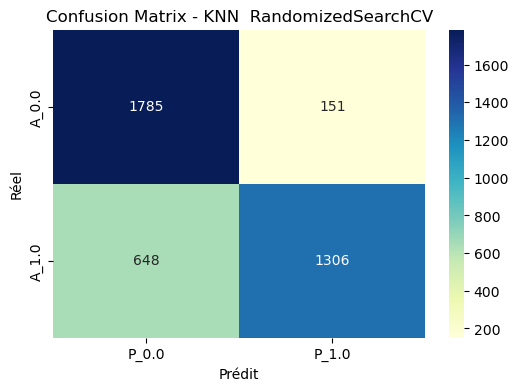


Classification Report – KNN  RandomizedSearchCV

              precision    recall  f1-score   support

         0.0       0.73      0.92      0.82      1936
         1.0       0.90      0.67      0.77      1954

    accuracy                           0.79      3890
   macro avg       0.82      0.80      0.79      3890
weighted avg       0.82      0.79      0.79      3890


Metrics – KNN  RandomizedSearchCV
Model              KNN  RandomizedSearchCV
AUC Score                         0.795188
MCC                               0.609879
Precision Score                   0.815389
Recall Score                      0.794602
f1-score                           0.79132
Accuracy Score                    0.794602
Train Accuracy                    0.872751
CV                                0.762886
dtype: object



In [23]:
param_dist_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

rs_knn = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_dist_knn,
    n_iter=10,
    scoring='accuracy',
    cv=5,
    n_jobs=6,
    verbose=1,
    random_state=42
)

rs_knn.fit(X_train_vec, y_train)
print("Best KNN params:", rs_knn.best_params_)

best_knn = rs_knn.best_estimator_

result_tabulation_rse1 = Model_Evaluation1(
    best_knn,
    "KNN  RandomizedSearchCV",
    X_train_vec, y_train,
    X_test_vec, y_test,
    result_tabulation_rse1
)

bert2


In [24]:
vote_classifi = VotingClassifier(estimators=[('Logistic Regression RandomizedSearchCV",',rs_lr ), ('SVC  RandomizedSearchCV', rs_svc)
],voting='soft')
best_model =vote_classifi.fit(X_train_vec,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 15 candidates, totalling 75 fits


In [27]:
best_model

VotingClassifier(estimators=[('Logistic Regression RandomizedSearchCV",',
                              RandomizedSearchCV(cv=5,
                                                 estimator=LogisticRegression(),
                                                 n_iter=20, n_jobs=4,
                                                 param_distributions={'C': array([1.00000000e-03, 4.64158883e-03, 2.15443469e-02, 1.00000000e-01,
       4.64158883e-01, 2.15443469e+00, 1.00000000e+01, 4.64158883e+01,
       2.15443469e+02, 1.00000000e+03]),
                                                                      'max_iter': [1000],
                                                                      'pe...
                              RandomizedSearchCV(cv=5, estimator=SVC(),
                                                 n_iter=15, n_jobs=4,
                                                 param_distributions={'C': array([1.00000000e-03, 3.59381366e-03, 1.29154967e-02, 4.64158883e-02,
       1.66810054e-01, 5.99484250e-01, 2.15443469e+00, 7.74263683e+00,
       2.78255940e+01, 1.00000000e+02]),
                                                                      'gamma': ['scale',
                                                                                'auto'],
                                                                      'kernel': ['linear',
                                                                                 'rbf']},
                                                 random_state=42,
                                                 scoring='accuracy',
                                                 verbose=1))],
                 voting='soft')

In [26]:
joblib.dump(best_model, f'best_model_tun{best_model_name.lower().replace(" ", "_")}.joblib')


NameError: name 'best_model_name' is not defined

Erreur: This 'RandomizedSearchCV' has no attribute 'predict_proba'
Le modèle SVC doit avoir probability=True pour le vote 'soft'
Utilisation du vote 'hard' à la place...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 15 candidates, totalling 75 fits
           ÉVALUATION DES PERFORMANCES - VOTING CLASSIFIER

🎯 MÉTRIQUES GLOBALES
----------------------------------------
📊 Accuracy (Précision globale)    : 0.8758 (87.58%)
📊 Precision (moyenne pondérée)    : 0.8829
📊 Recall (moyenne pondérée)       : 0.8758
📊 F1-Score (moyenne pondérée)     : 0.8753
📊 AUC-ROC                         : Non disponible (vote 'hard')

🔍 MATRICE DE CONFUSION
----------------------------------------
Matrice de confusion (lignes=réel, colonnes=prédiction):
[[1826  110]
 [ 373 1581]]


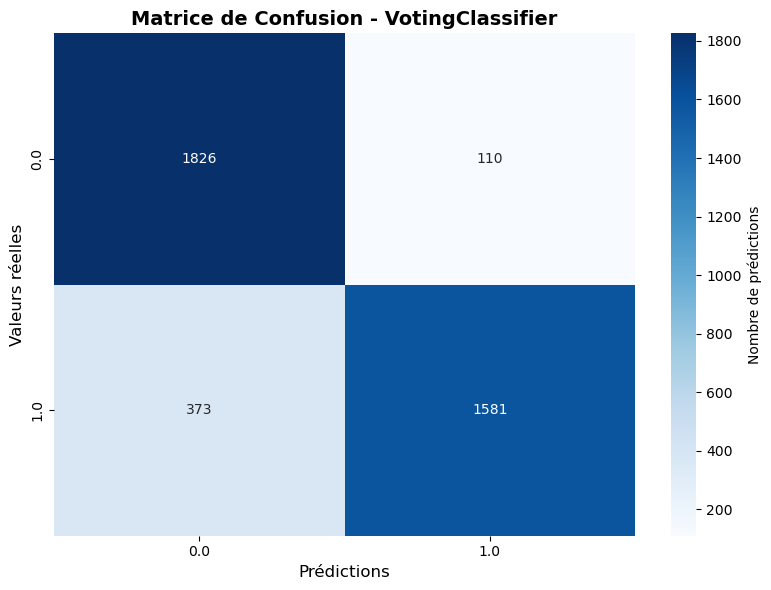


📋 RAPPORT DE CLASSIFICATION DÉTAILLÉ
--------------------------------------------------
              precision    recall  f1-score   support

         0.0       0.83      0.94      0.88      1936
         1.0       0.93      0.81      0.87      1954

    accuracy                           0.88      3890
   macro avg       0.88      0.88      0.88      3890
weighted avg       0.88      0.88      0.88      3890



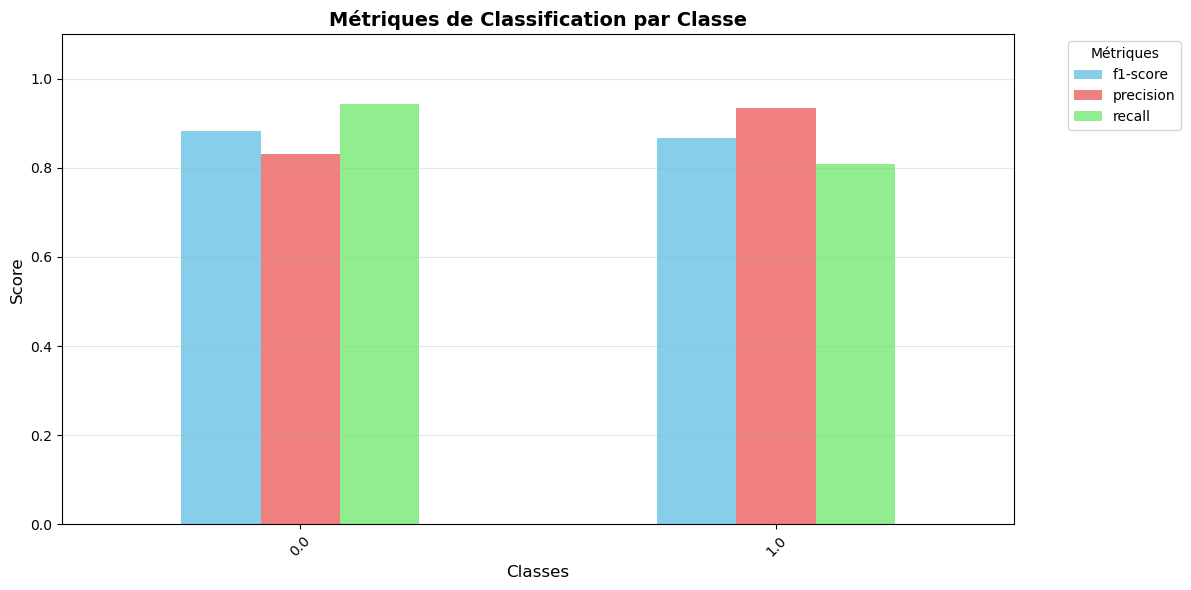


🔎 ANALYSE DES ERREURS
------------------------------
Total des prédictions           : 3890
Prédictions correctes           : 3407
Prédictions incorrectes         : 483
Taux d'erreur                   : 12.42%

                    RÉSUMÉ FINAL
🏆 Modèle utilisé               : VotingClassifier
🏆 Type de vote                 : Hard
🏆 Accuracy finale              : 0.8758 (87.58%)
🏆 F1-Score global              : 0.8753
🏆 Stratégie                   : Vote majoritaire
🏆 Modèles combinés             : Logistic Regression + SVC


In [28]:
# Importation des bibliothèques nécessaires
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    roc_auc_score
)
import pandas as pd

# Prédictions sur l'ensemble de test
try:
    y_pred = best_model.predict(X_test_vec)
    y_pred_proba = best_model.predict_proba(X_test_vec)
    proba_available = True
except AttributeError as e:
    print(f"Erreur: {e}")
    print("Le modèle SVC doit avoir probability=True pour le vote 'soft'")
    print("Utilisation du vote 'hard' à la place...")
    
    # Reconfigurer avec vote 'hard'
    vote_classifi_hard = VotingClassifier(
        estimators=[
            ('Logistic Regression RandomizedSearchCV', rs_lr), 
            ('SVC RandomizedSearchCV', rs_svc)
        ],
        voting='hard'
    )
    best_model = vote_classifi_hard.fit(X_train_vec, y_train)
    y_pred = best_model.predict(X_test_vec)
    y_pred_proba = None
    proba_available = False

print("="*70)
print("           ÉVALUATION DES PERFORMANCES - VOTING CLASSIFIER")
print("="*70)

# 1. MÉTRIQUES GLOBALES
print("\n🎯 MÉTRIQUES GLOBALES")
print("-" * 40)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"📊 Accuracy (Précision globale)    : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"📊 Precision (moyenne pondérée)    : {precision:.4f}")
print(f"📊 Recall (moyenne pondérée)       : {recall:.4f}")
print(f"📊 F1-Score (moyenne pondérée)     : {f1:.4f}")

# AUC si disponible et problème binaire
if len(np.unique(y_test)) == 2 and proba_available:
    auc = roc_auc_score(y_test, y_pred_proba[:, 1])
    print(f"📊 AUC-ROC                         : {auc:.4f}")
elif len(np.unique(y_test)) == 2:
    print(f"📊 AUC-ROC                         : Non disponible (vote 'hard')")

# 2. MATRICE DE CONFUSION
print("\n🔍 MATRICE DE CONFUSION")
print("-" * 40)
cm = confusion_matrix(y_test, y_pred)
print("Matrice de confusion (lignes=réel, colonnes=prédiction):")
print(cm)

# Visualisation de la matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(np.unique(y_test)), 
            yticklabels=sorted(np.unique(y_test)),
            cbar_kws={'label': 'Nombre de prédictions'})
plt.title('Matrice de Confusion - VotingClassifier', fontsize=14, fontweight='bold')
plt.xlabel('Prédictions', fontsize=12)
plt.ylabel('Valeurs réelles', fontsize=12)
plt.tight_layout()
plt.show()

# 3. RAPPORT DE CLASSIFICATION DÉTAILLÉ
print("\n📋 RAPPORT DE CLASSIFICATION DÉTAILLÉ")
print("-" * 50)
print(classification_report(y_test, y_pred))

# Visualisation du rapport de classification
report_dict = classification_report(y_test, y_pred, output_dict=True)

# Extraire les classes (exclure les moyennes)
classes = [key for key in report_dict.keys() if key not in ['accuracy', 'macro avg', 'weighted avg']]
metrics = ['precision', 'recall', 'f1-score']

# Créer le DataFrame pour la visualisation
data = []
for cls in classes:
    for metric in metrics:
        data.append({
            'Classe': cls,
            'Métrique': metric,
            'Valeur': report_dict[cls][metric]
        })

df_report = pd.DataFrame(data)

# Graphique en barres groupées
plt.figure(figsize=(12, 6))
pivot_df = df_report.pivot(index='Classe', columns='Métrique', values='Valeur')
pivot_df.plot(kind='bar', ax=plt.gca(), color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Métriques de Classification par Classe', fontsize=14, fontweight='bold')
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend(title='Métriques', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 4. ANALYSE DES ERREURS
print("\n🔎 ANALYSE DES ERREURS")
print("-" * 30)
total_predictions = len(y_test)
correct_predictions = (y_pred == y_test).sum()
incorrect_predictions = total_predictions - correct_predictions

print(f"Total des prédictions           : {total_predictions}")
print(f"Prédictions correctes           : {correct_predictions}")
print(f"Prédictions incorrectes         : {incorrect_predictions}")
print(f"Taux d'erreur                   : {(incorrect_predictions/total_predictions)*100:.2f}%")

# 5. RÉSUMÉ FINAL
print("\n" + "="*70)
print("                    RÉSUMÉ FINAL")
print("="*70)
print(f"🏆 Modèle utilisé               : VotingClassifier")
print(f"🏆 Type de vote                 : {'Soft' if proba_available else 'Hard'}")
print(f"🏆 Accuracy finale              : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"🏆 F1-Score global              : {f1:.4f}")

if proba_available:
    print("🏆 Stratégie                   : Combinaison des probabilités")
else:
    print("🏆 Stratégie                   : Vote majoritaire")

print("🏆 Modèles combinés             : Logistic Regression + SVC")
print("="*70)